In [86]:
import sys
sys.path.insert(0, '..')

In [87]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [88]:
wf_wid = 512
wid = 80
oversample = 4

nwavels = 3
npoly=1

n_modes = 40
n_zernikes = 30

resolved_wid = 1

optics = NICMOSCoronagraph(wf_wid, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

# vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]
# assert vects.shape == (nwavels, npoly)
# spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

# extra_bad = np.full((wid,wid), False).at[30:50, 30:50].set(True)#.at[:, 35:45].set(True)


exposures_single = [
    exposure_from_file(ddir + 'n8jv51u6q_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F187N"), crop=wid, extra_bad=np.load("bad_map.npy"), flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


159.962 5.4
Version 4.1.1
-100.43


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


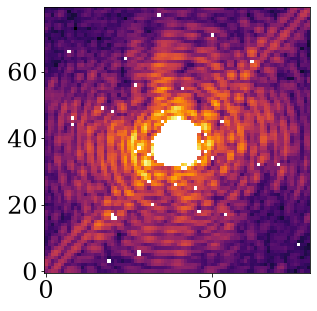

In [89]:
plt.imshow(exposures_single[0].data**0.125)

In [90]:
256-181,256-44

(75, 212)

In [91]:
exposures_single[0].hdr["TARSIAFY"]

211.546

In [92]:
# np.array([
#         256-181 - np.array(exp.hdr["TARSIAFX"],dtype=float), 
#         256-44 - np.array(exp.hdr["TARSIAFY"],dtype=float)
#     ])*0.075

In [93]:
exposures_single[0].target

'BD+032954'

In [94]:
(np.nansum(exposures_single[0].data)/nwavels)*4

Array(21255.61331779, dtype=float64)

In [ ]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},
    "primary_shear": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(2)+1,
    "fnumber": 45.7,
    "anisotropy": 1.+1e-5,

    "outer_radius": 1.2*0.9768,
    "secondary_radius": 0.357*1.2,
    "spider_width": 0.072*1.2,
    "primary_spider": 0.0256,
    "primary_secondary": 0.330*1.2,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*10)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.75, 0.05])*0.075#np.array([-0.05, -0.75])*0.075
    # params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181), 
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)
    ])*0.075


    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.zeros(16).at[0].set(120.)#np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 2.5#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -0.6##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.06,-0.06])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

30.119887558990886


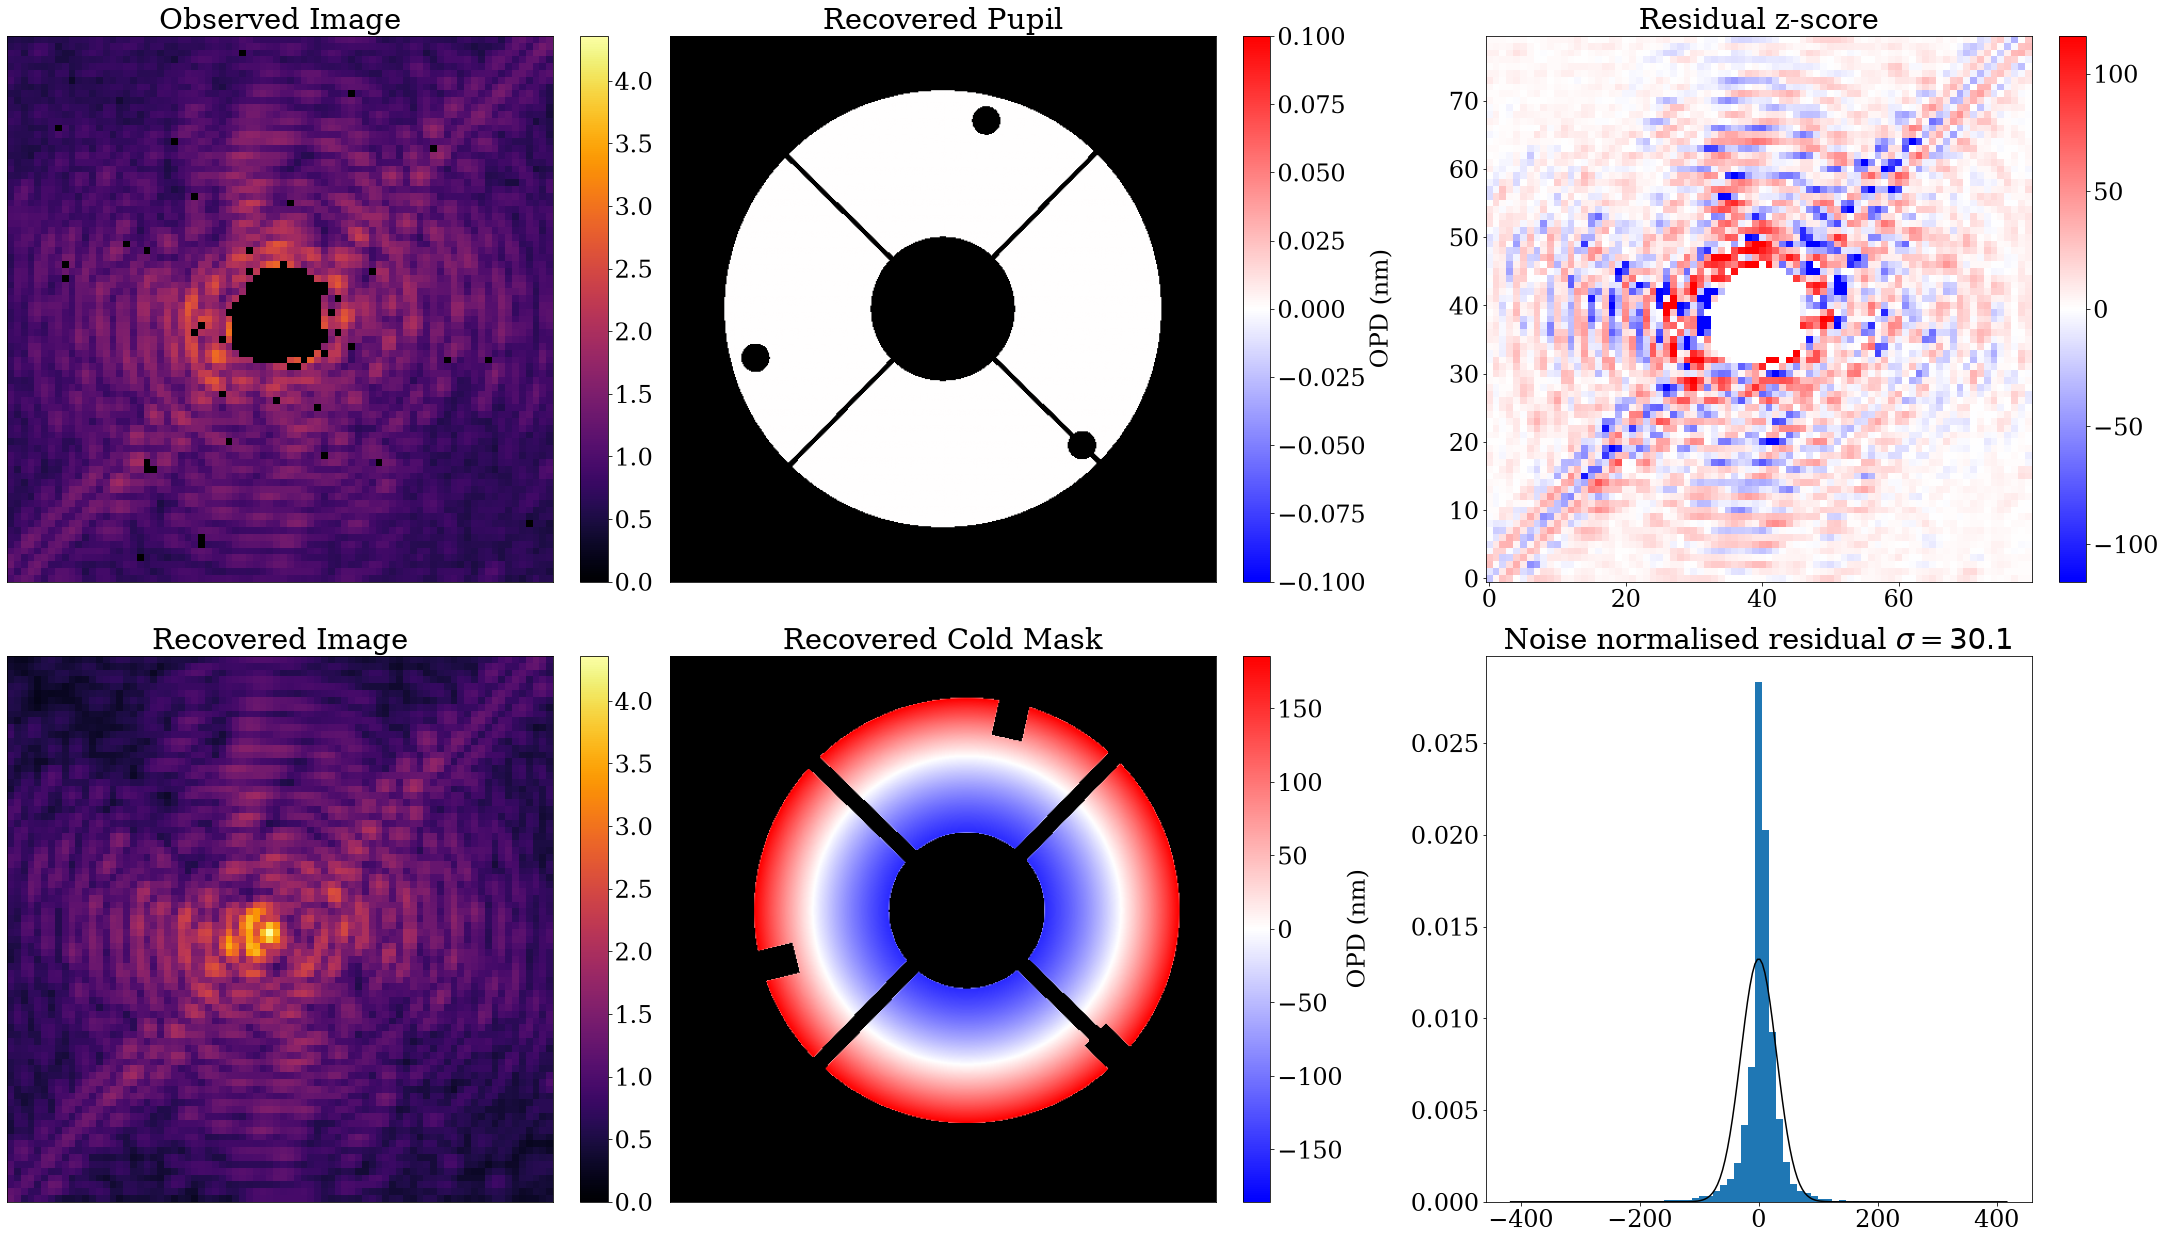

In [96]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=wf_wid)

In [97]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "primary_opd": sgd(g*2, 0),

    "spectrum": sgd(g*1, 0),
    "primary_tilt": sgd(g*1., 0),
    "cold_mask_tilt": sgd(g*1, 0),
    "cold_mask_opd": sgd(g*1., 0),

    "bias": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*1, 0),
    "cold_mask_rot": sgd(g*5., 50),
    "primary_rot": sgd(g*3., 0),

    "primary_low": sgd(g*1, 0),

    "cold_mask_scale": sgd(g*1, 0),
    "cold_mask_shear": sgd(g*1, 0),

    "primary_shear": sgd(g*1, 0),
    # "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 0),
    "occulter_coeffs": sgd(g*1, 0),

    "secondary_radius": sgd(g*1., 0),
    "spider_width": sgd(g*1., 0),
    "primary_spider": sgd(g*1., 0),
    "primary_secondary": sgd(g*1., 0),

    "fnumber": sgd(g*1., 0),
    "anisotropy": sgd(g*1., 0),


}

things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*3., 15.),
    "cold_mask_tilt": sgd(g*0.3, 0),
    "cold_mask_opd": sgd(g*0.2, 40),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*10., 70),
    "cold_mask_rot": sgd(g*3., 85),
    "primary_rot": sgd(g*20., 85),

    "primary_low": sgd(g*0.05, 150),

    "cold_mask_scale": sgd(g*5, 100),
    "cold_mask_shear": sgd(g*10, 100),

    "primary_shear": sgd(g*5, 100),
    # "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 120),
    "occulter_coeffs": sgd(g*1, 120),

    # "outer_radius": sgd(g*1., 120),
    "secondary_radius": sgd(g*1., 120),
    "spider_width": sgd(g*1., 120),
    "primary_spider": sgd(g*1., 120),
    "primary_secondary": sgd(g*1., 120),

    "fnumber": sgd(g*1., 200),
    "anisotropy": sgd(g*2., 200),
}

groups = list(things.keys())

In [98]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [99]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 600, nbatches=20)

  0%|          | 0/600 [00:00<?, ?it/s]

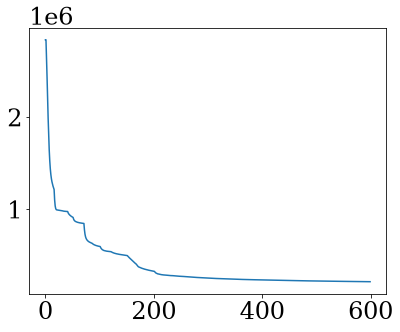

In [100]:
plt.plot(losses[:])

20
8.480612061987946


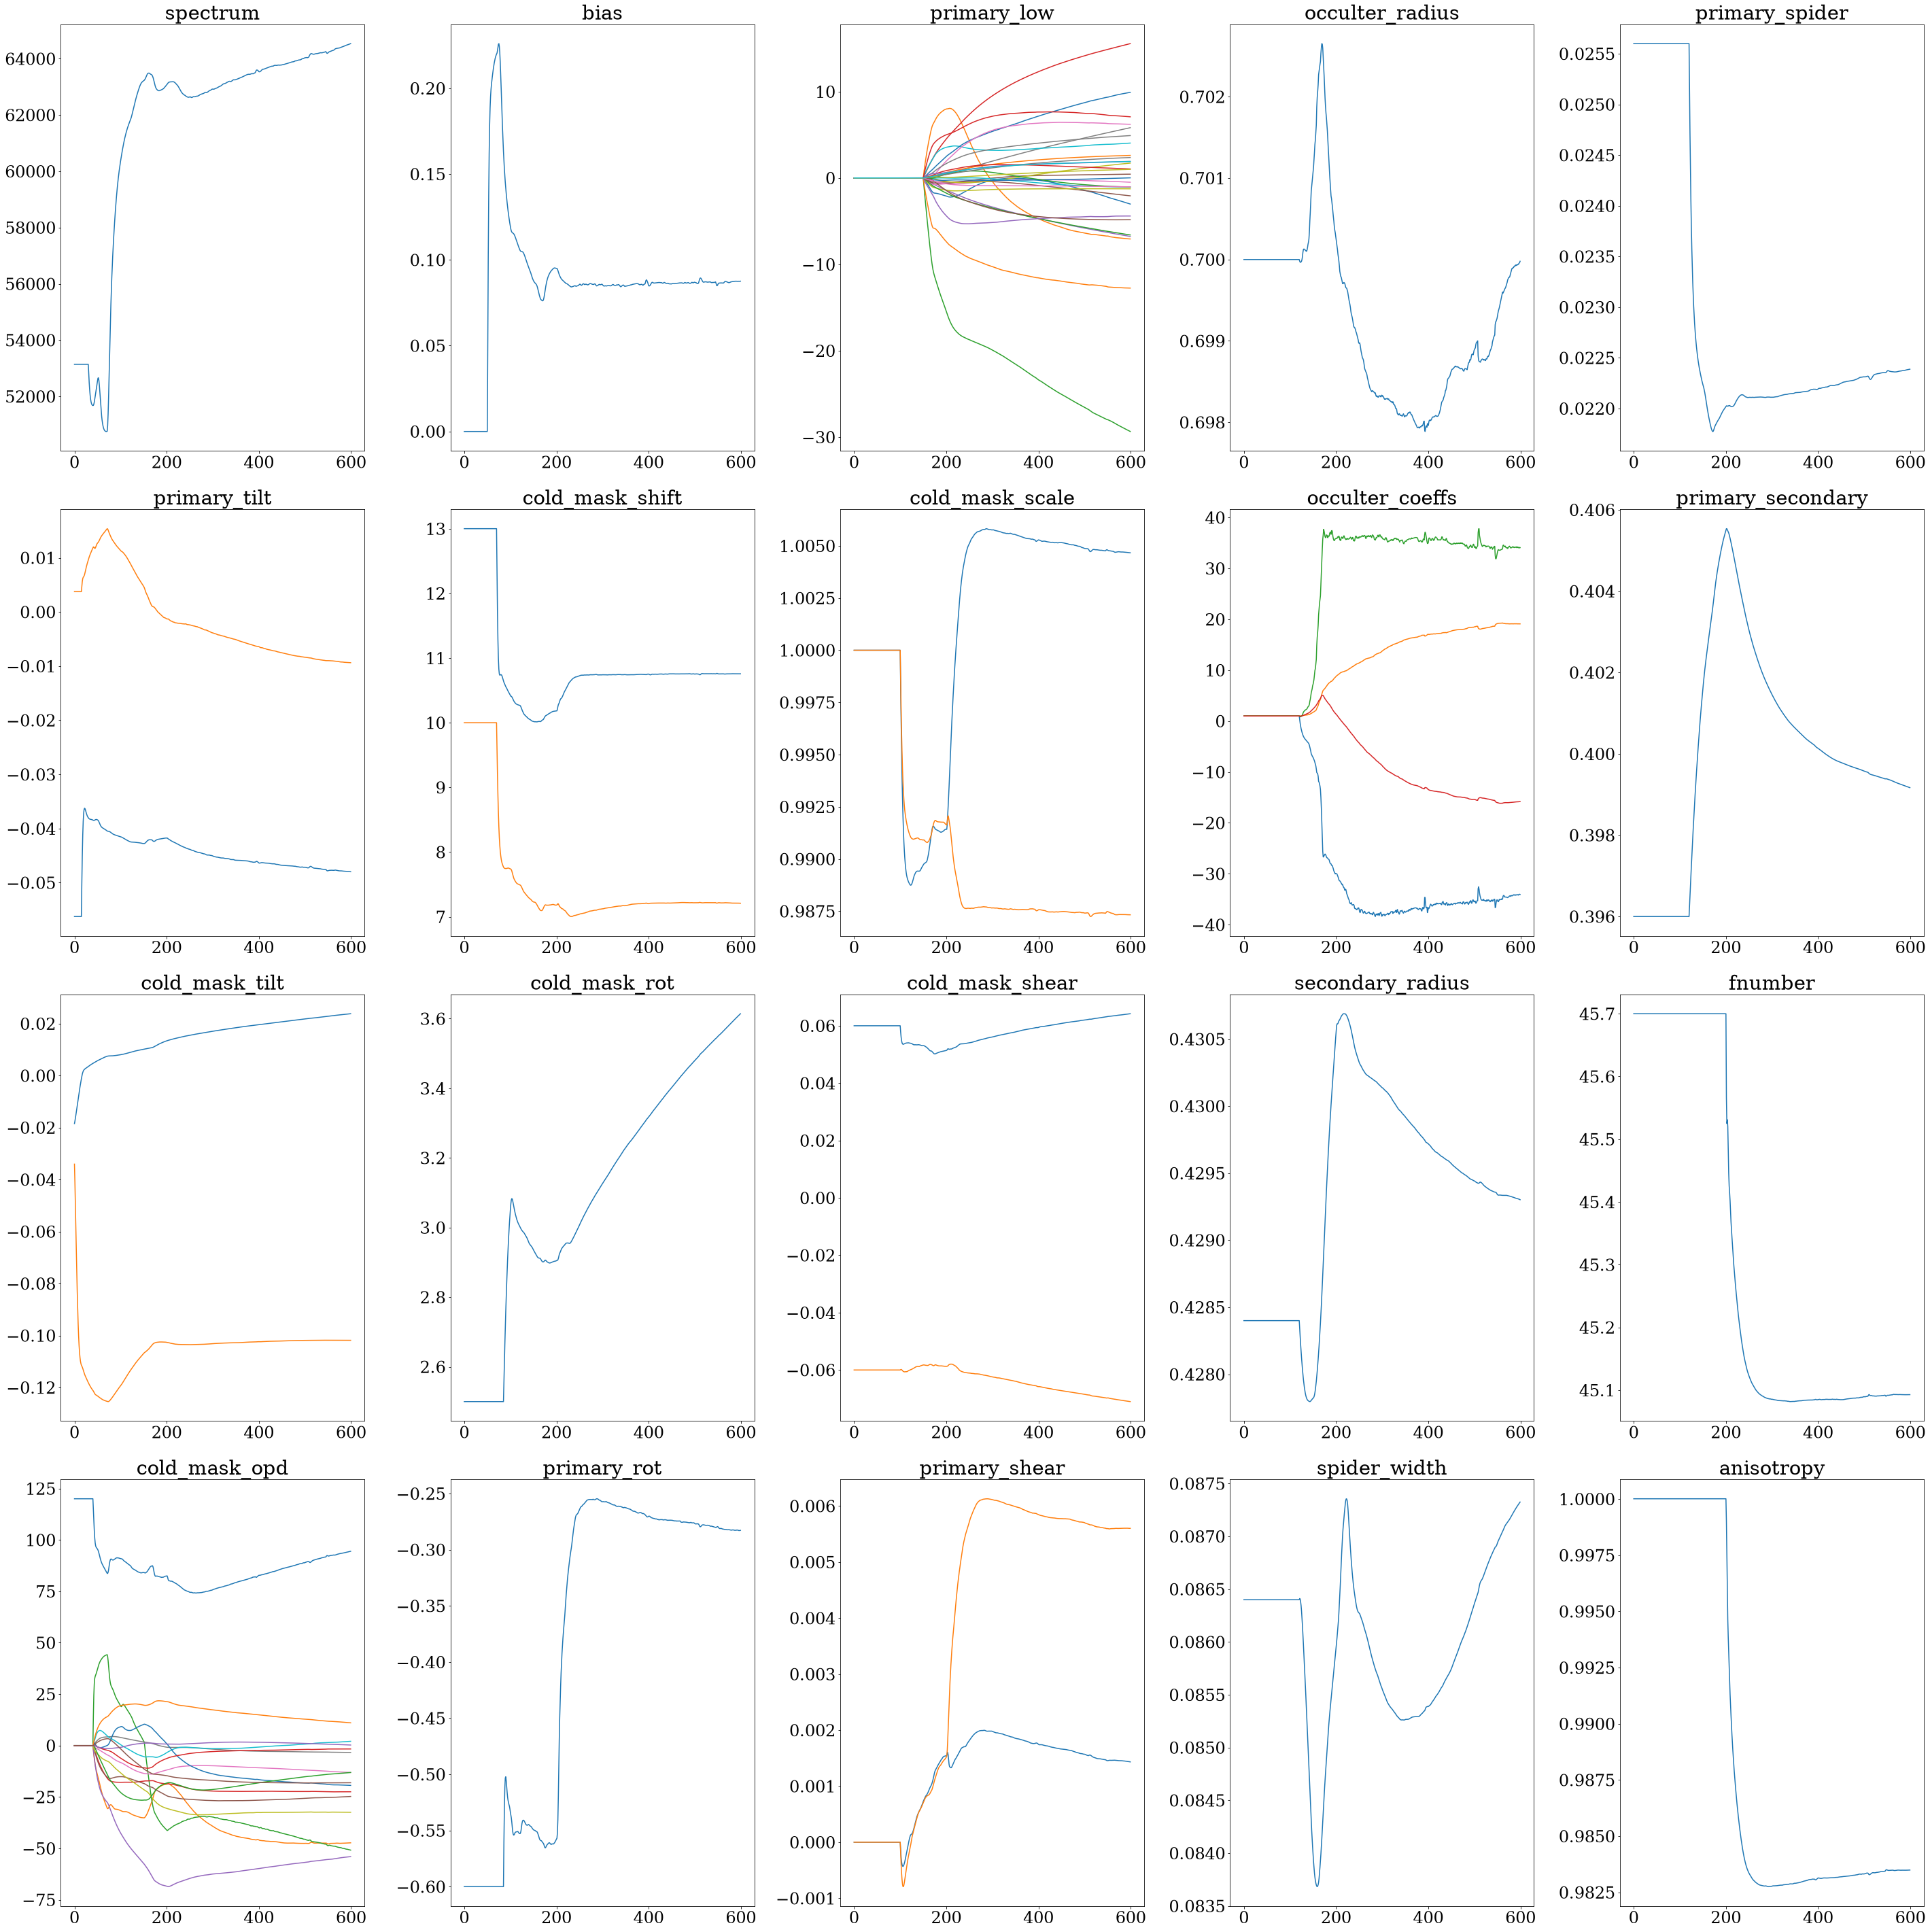

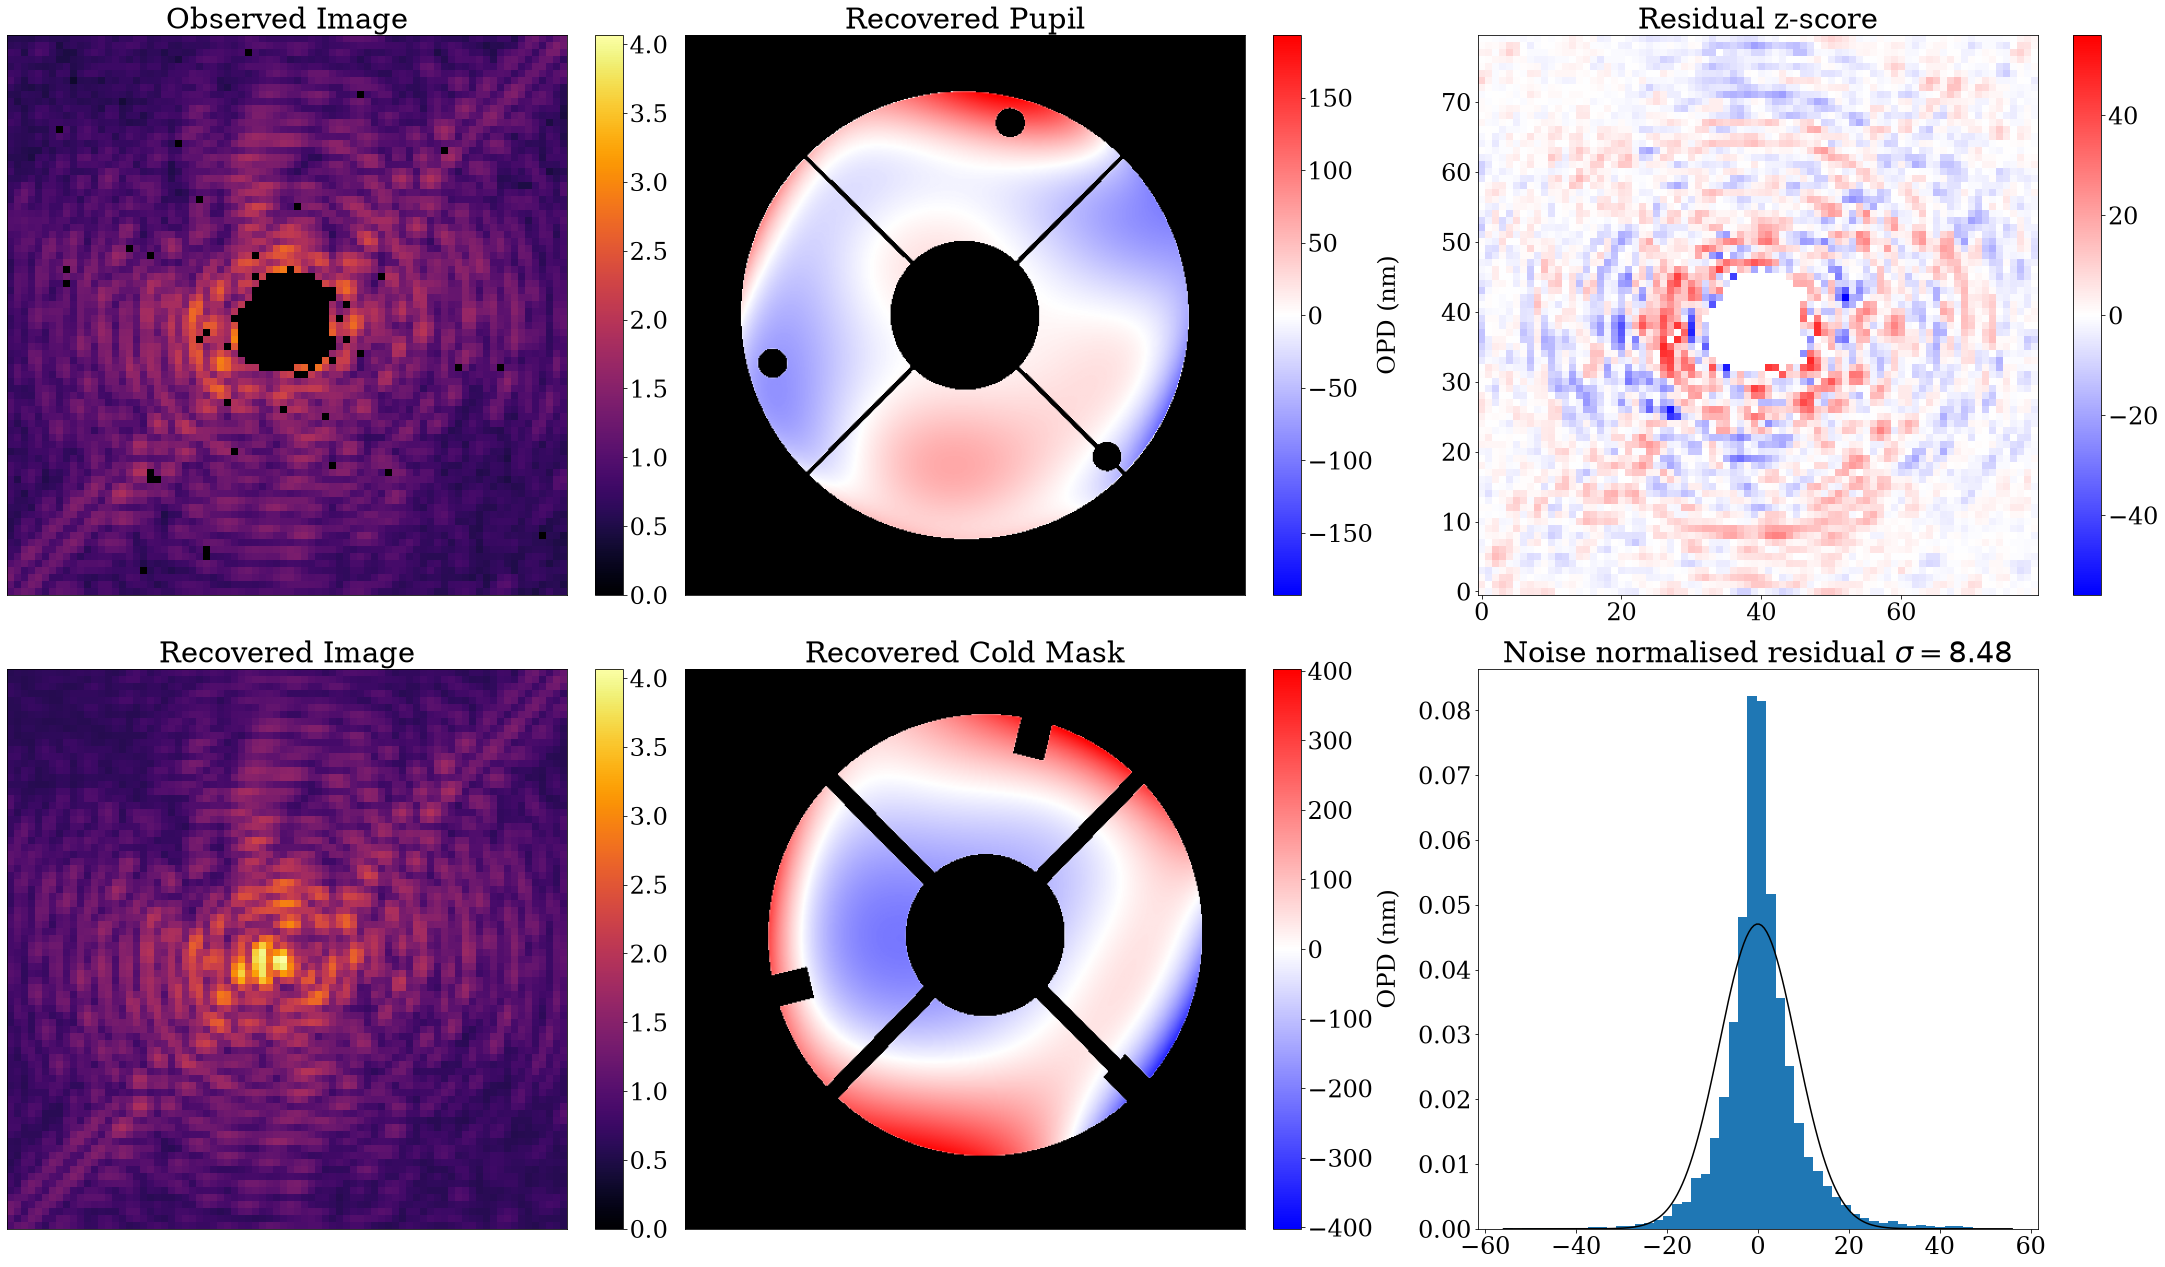

In [101]:
plot_params(params_history, list(things_start.keys()), xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=100, quadrature=False, wf_size=wf_wid)

In [102]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])

In [103]:
dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)

Wavefront(
  phasor=c128[128,128], wavelength=f64[], pixel_scale=f64[], center=f64[1]
)

In [104]:
dlu.arcsec2rad(0.3)*24*2.4

8.37758040957278e-05

In [105]:
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

In [106]:
# testocculter = CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1)+3e-3, np.zeros(1))
final_optics.occulter.layers["occulter"]

CLIMBOcculter(r=f64[], cc=f64[2], ss=f64[2], normalise=False)

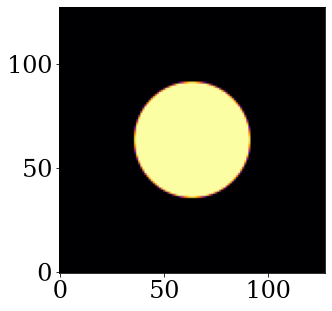

In [107]:
plt.imshow(np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

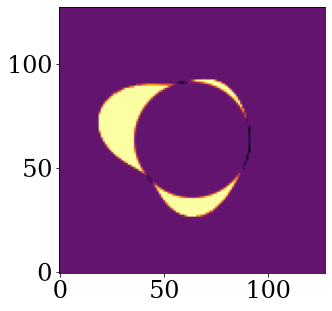

In [108]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

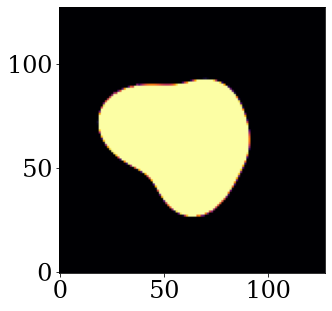

In [109]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [110]:
params_history[-1]

{'anisotropy': Array(0.98349221, dtype=float64),
 'bias': {'n8jv51u6q': Array(0.08758656, dtype=float64)},
 'cold_mask_opd': {'global': Array([ 94.46332882, -47.29597444, -50.83472508, -22.47380051,
         -54.00226551, -24.75158026, -13.06492989,  -3.33459681,
         -32.45113411,   2.06747084, -19.36747918,  11.04982644,
         -13.11487669,  -1.65344128,   0.25794623, -18.07905375],      dtype=float64)},
 'cold_mask_rot': {'global': Array(3.61410392, dtype=float64)},
 'cold_mask_scale': {'global': Array([1.00466673, 0.98732871], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.06419492, -0.07101703], dtype=float64)},
 'cold_mask_shift': {'global': Array([10.75620287,  7.20885362], dtype=float64)},
 'cold_mask_tilt': {'global': Array([ 0.02381055, -0.10184786], dtype=float64)},
 'fnumber': Array(45.09279269, dtype=float64),
 'occulter_coeffs': Array([-34.06950686,  19.0991108 ,  34.08520093, -15.81946824], dtype=float64),
 'occulter_radius': Array(0.69997855, dtype=flo

In [111]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [112]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 3000, nbatches=200)

  0%|          | 0/3000 [00:00<?, ?it/s]

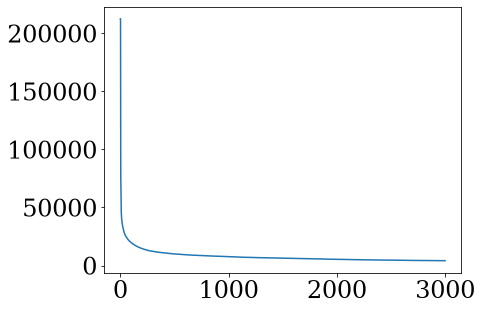

In [113]:
plt.plot(losses[:])

In [114]:
losses[-1]

Array(4175.14357152, dtype=float64)

21
2.236886446442094


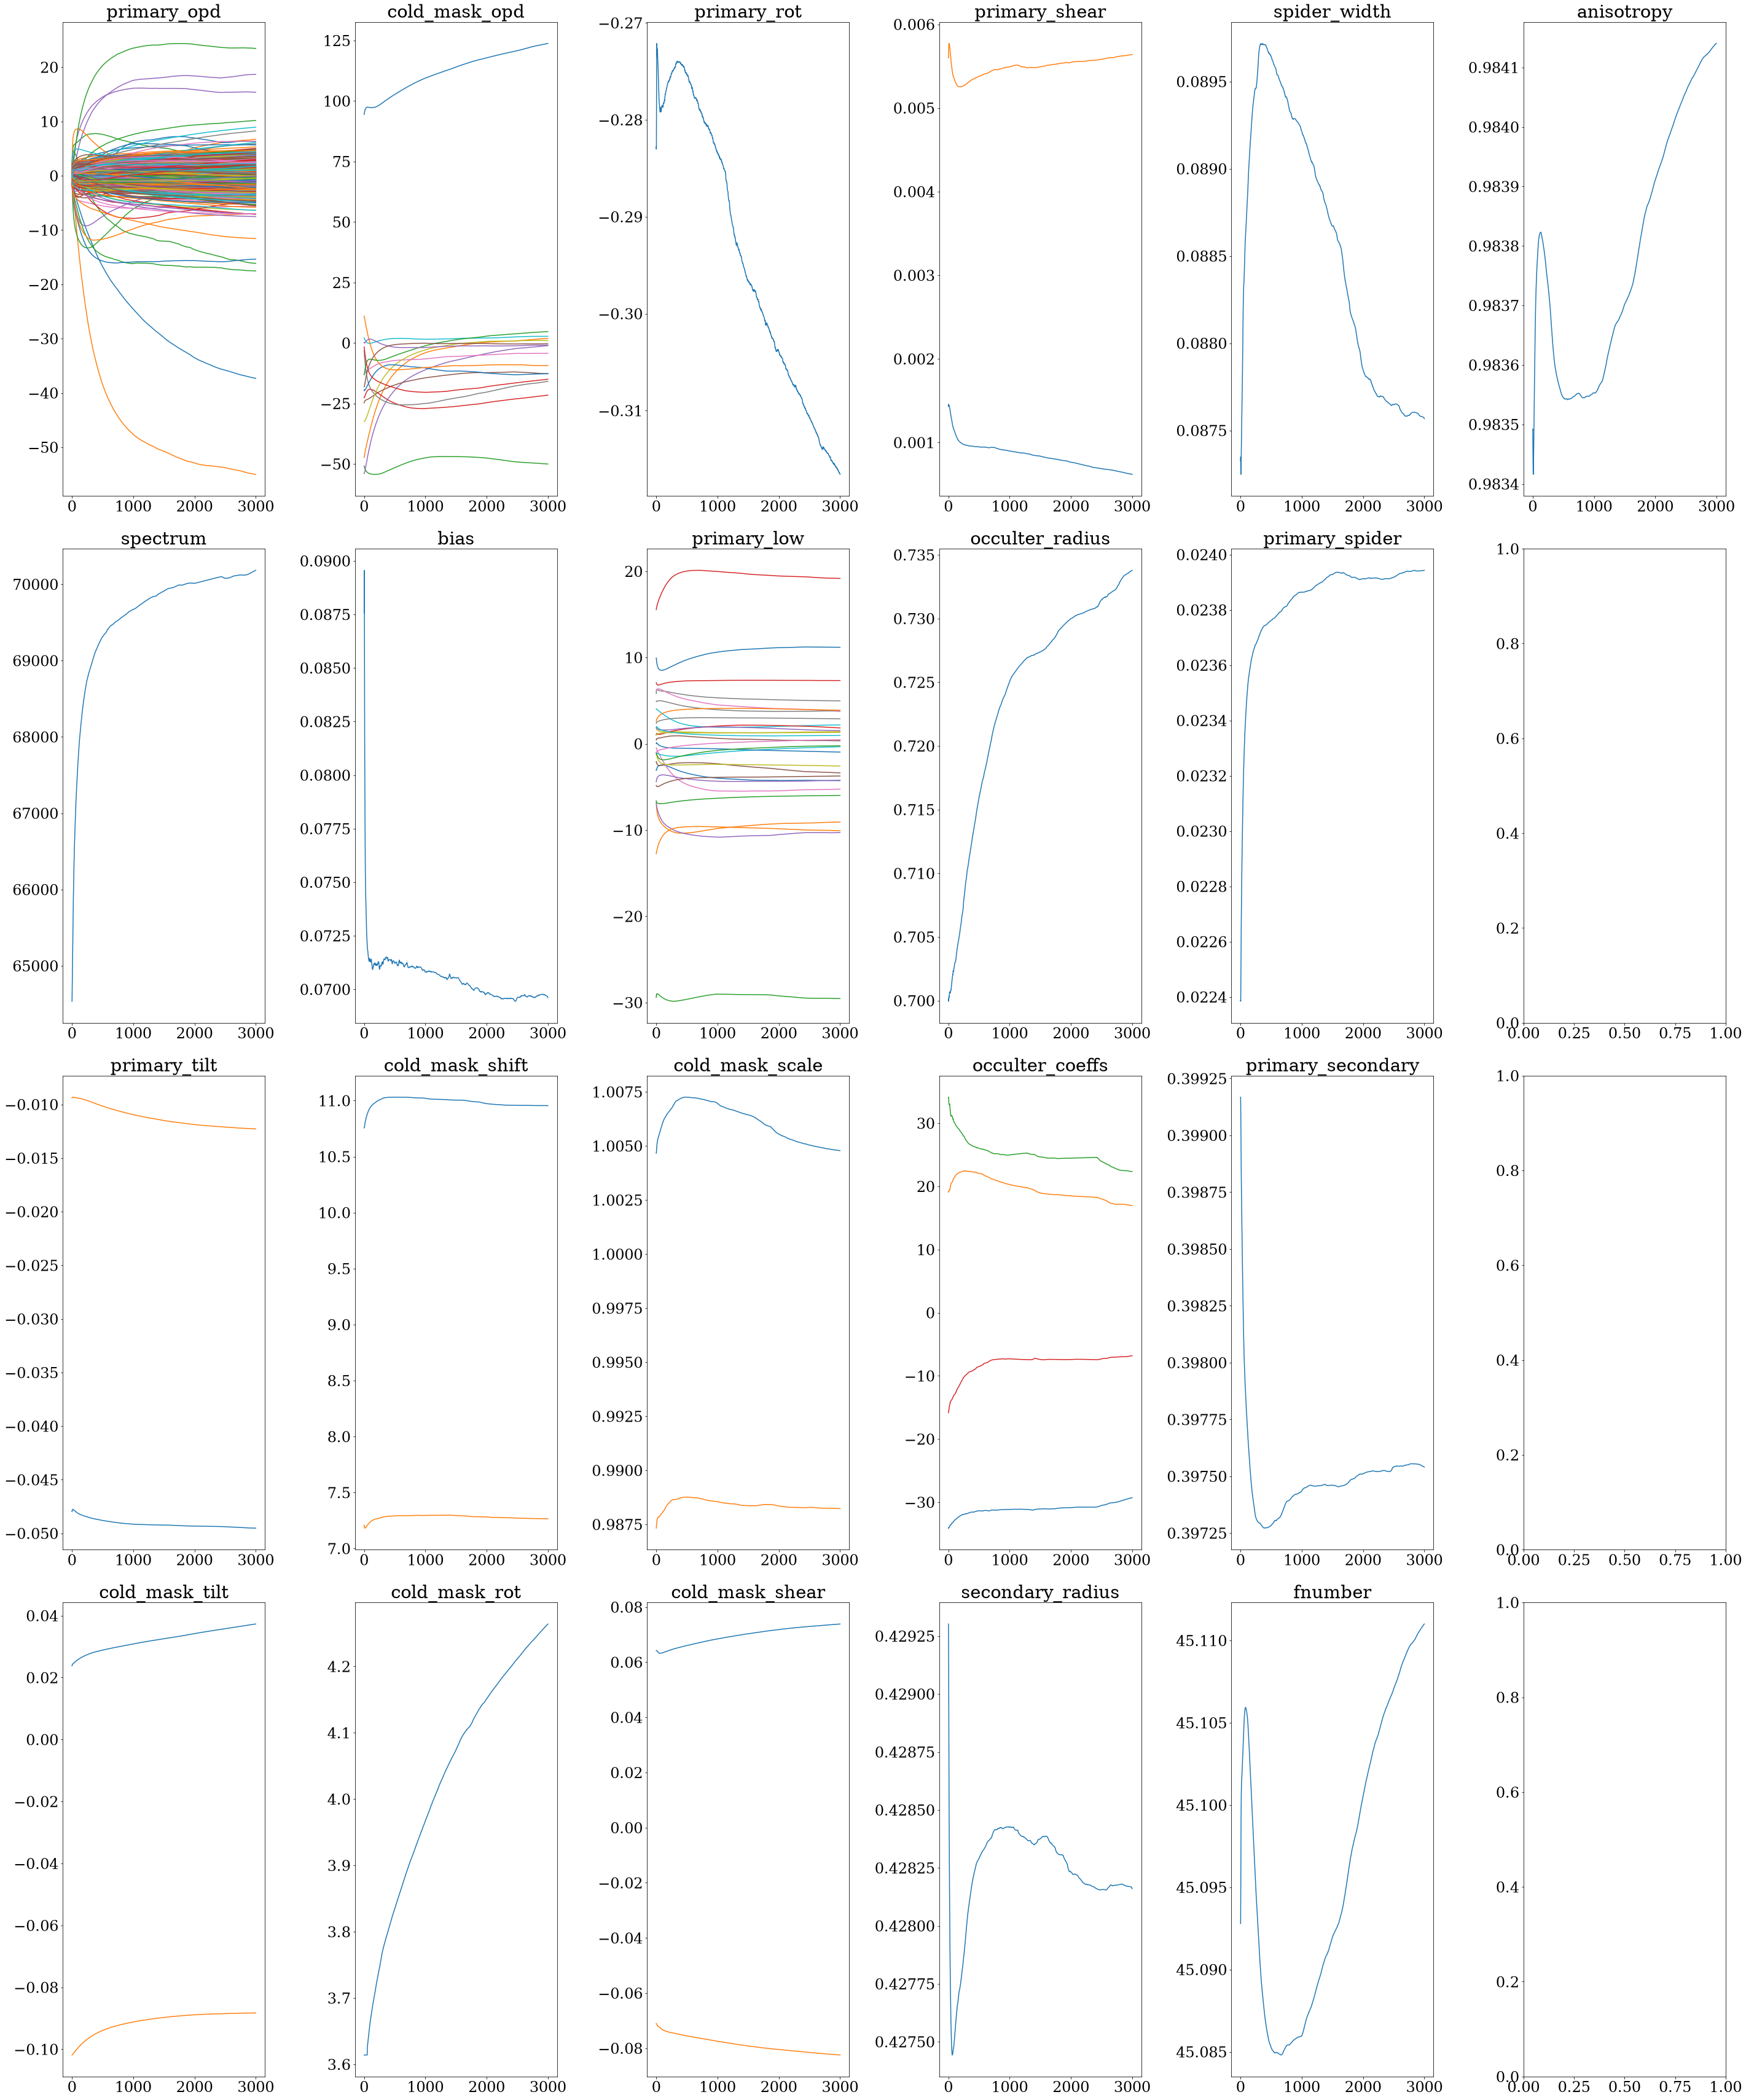

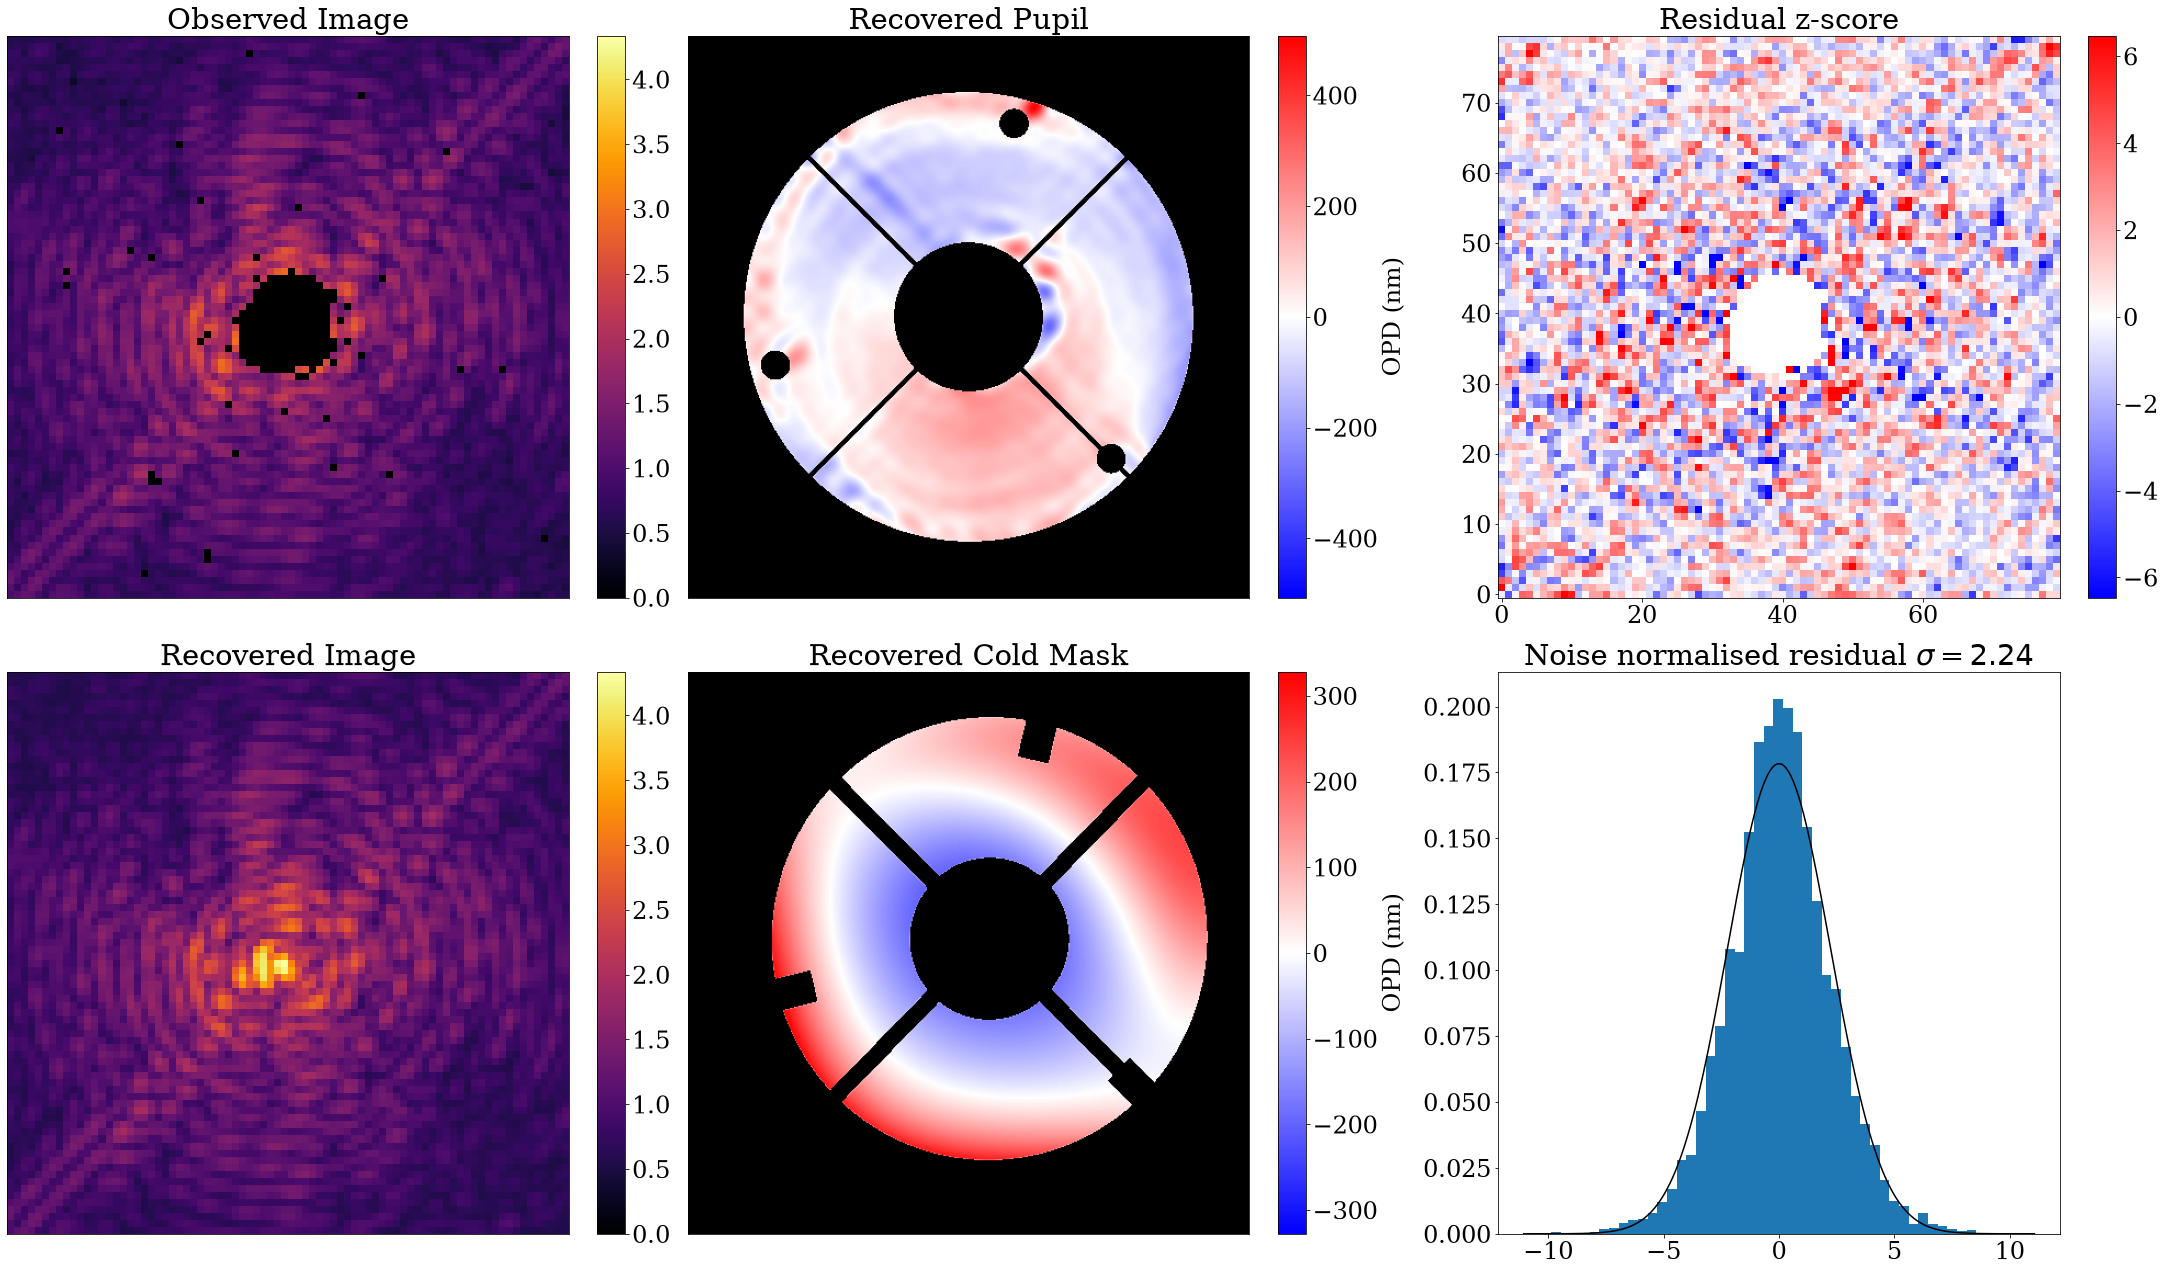

In [115]:
plot_params(params_history, groups, xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False, wf_size=wf_wid, percentile=99)

([], [])

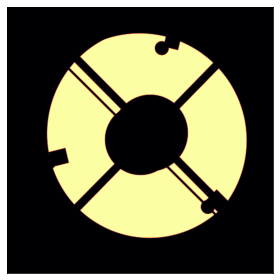

In [116]:
model = ModelParams(params_history[-1]).inject(model_single)
optics = exposures_single[0].fit.update_optics(model, exposures_single[0])
coords = dlu.pixel_coords(512, model.optics.diameter)
support = optics.primary.transmission(coords,2.4/512) * optics.cold_mask.transmission(coords,2.4/512)
plt.imshow(support)
plt.xticks([])
plt.yticks([])

([], [])

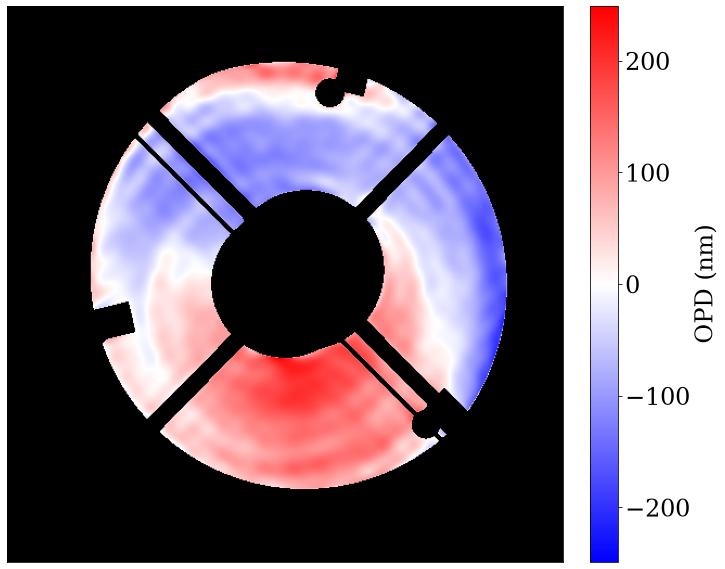

In [117]:
plt.figure(figsize=(10,10), layout="compressed")
opd = (optics.primary_opd.eval_basis() + optics.primary_low.eval_basis(coords))*1e9
support_mask = support.at[support < .5].set(np.nan)

cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)
olim = np.nanmax(np.abs(opd*support_mask))
plt.imshow(support_mask*opd,cmap=cmap,vmin=-olim, vmax=olim)
plt.colorbar().set_label("OPD (nm)")
plt.xticks([])
plt.yticks([])

In [118]:
np.sqrt(3**2 * 100)

Array(30., dtype=float64, weak_type=True)

In [119]:
params_history[-1]

{'anisotropy': Array(0.9841403, dtype=float64),
 'bias': {'n8jv51u6q': Array(0.069611, dtype=float64)},
 'cold_mask_opd': {'global': Array([123.77843146,   1.87687004, -50.01704152, -21.55072807,
          -1.10246467, -12.6663934 ,  -4.29248044, -15.87510898,
           0.95296512,   2.75748231, -12.71503221,  -9.35118313,
           4.71591304, -14.99978223,  -0.93389191,  -0.32742545],      dtype=float64)},
 'cold_mask_rot': {'global': Array(4.26393416, dtype=float64)},
 'cold_mask_scale': {'global': Array([1.00478209, 0.98822831], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.07385511, -0.08244549], dtype=float64)},
 'cold_mask_shift': {'global': Array([10.95512399,  7.26640311], dtype=float64)},
 'cold_mask_tilt': {'global': Array([ 0.03730245, -0.08827728], dtype=float64)},
 'fnumber': Array(45.11100128, dtype=float64),
 'occulter_coeffs': Array([-29.28198717,  16.95481592,  22.36274528,  -6.81278657], dtype=float64),
 'occulter_radius': Array(0.73379157, dtype=float6

In [120]:
np.save("params.npy", params_history[-1])

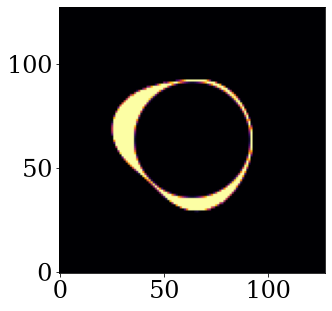

In [121]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [122]:
jsp.stats.norm.logpdf(200, 1, 1)

Array(-19801.41893853, dtype=float64, weak_type=True)

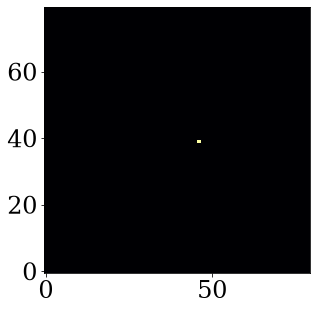

In [123]:
final_model = ModelParams(params_history[-1]).inject(model_single)


for exp in exposures_single:
    fit = exp.fit(model, exp)
    resid = np.nan_to_num((exp.data - fit)/exp.err)
    bad_map = np.abs(resid)>10
    plt.imshow(bad_map)

In [124]:
# np.save("bad_map.npy", bad_map)